In [1]:
# 1. Import necessary libraries

# Numpy: For numerical computations, such as handling arrays and matrices.
import numpy as np

# Pandas: For data analysis and manipulation, especially useful for loading and handling tabular data.
import pandas as pd

# Scikit-learn: For building, training, and evaluating machine learning models.
# - train_test_split: For splitting the dataset into training and testing sets.
# - KNeighborsClassifier: A classifier based on the K-Nearest Neighbors algorithm.
# - confusion_matrix, accuracy_score, classification_report: For evaluating model performance.
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Matplotlib and Seaborn: For visualizing data and evaluation results.
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Load the dataset

# Load the stroke prediction dataset (Make sure the path to the dataset is correct)
stroke_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Display the first few rows of the dataset
stroke_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# 3. Handle missing values
# Some rows in the 'bmi' column have missing values, which we handle by filling them with the median BMI value.
stroke_data['bmi'] = stroke_data['bmi'].fillna(stroke_data['bmi'].median())

# Check for missing values in the dataset after filling
stroke_data.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [5]:
# 4. Analyze and preprocess the data

# Count the number of instances for each class (0 = No Stroke, 1 = Stroke)
stroke_data['stroke'].value_counts()

0    4861
1     249
Name: stroke, dtype: int64

In [6]:
# 5. Convert categorical features to numerical
# Categorical variables (e.g., gender, work type) are converted to numerical values using the factorize method.
# Factorize assigns unique integers to each category, making them usable by machine learning models.
categorical_columns = stroke_data.select_dtypes(['object']).columns
stroke_data[categorical_columns] = stroke_data[categorical_columns].apply(lambda x: pd.factorize(x)[0])

# Display the dataset after transformation
stroke_data.head(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,0,0,0,228.69,36.6,0,1
1,51676,1,61.0,0,0,0,1,1,202.21,28.1,1,1


In [7]:
# 6. Drop unnecessary columns
# We remove the 'id' column since it's not relevant for prediction.
stroke_data = stroke_data.drop(columns=['id'])

# Display the dataset after removing the 'id' column
stroke_data.head(2)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
1,1,61.0,0,0,0,1,1,202.21,28.1,1,1


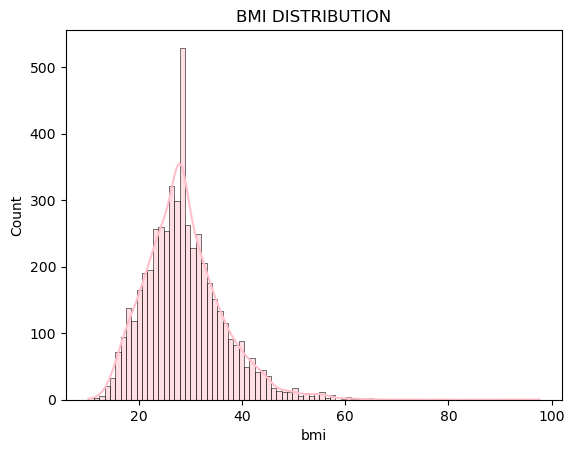

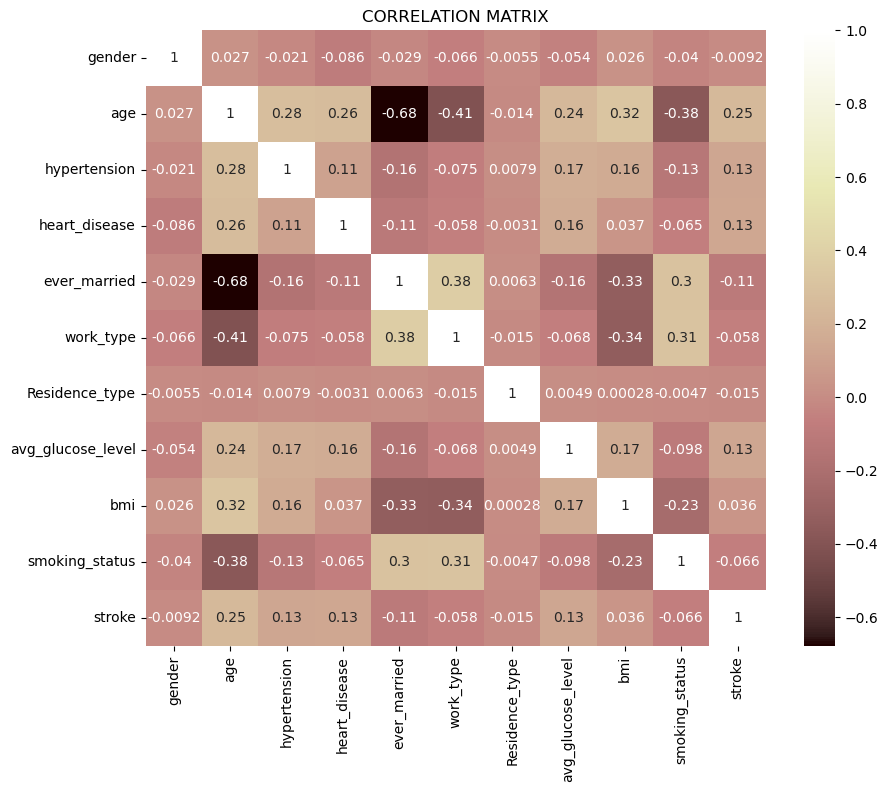

In [17]:
# 7. Visualize data distributions and correlations
# Generate a pair plot to visualize pairwise relationships and distributions of numerical features 
#sns.pairplot(strokeData)
# Plot the distribution of the 'bmi' numerical feature with a KDE (Kernel Density Estimate) overlay 
sns.histplot(stroke_data['bmi'].dropna(), kde=True, color='pink')
plt.title('BMI DISTRIBUTION')
plt.show()

# Plot the correlation matrix with a pink color palette
plt.figure(figsize=(10, 8))
sns.heatmap(stroke_data.corr(), annot=True, cmap='pink')
plt.title('CORRELATION MATRIX')
plt.show()

In [9]:
# 8. Define feature matrix (X) and target variable (y)
# - X (features): All columns except the target column 'stroke'.
# - y (target): The 'stroke' column which indicates if the individual had a stroke.
X = stroke_data.drop(columns=['stroke'])
y = stroke_data['stroke']

In [10]:
# 9. Split the dataset into training and testing sets
# We split the data into 80% training and 20% testing sets to evaluate the model later on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Display first few rows of training data
X_train.head()

# Display first few rows of testing data
X_test.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
2918,1,63.0,0,1,0,1,1,239.95,32.2,2
3056,0,62.0,0,1,0,2,1,73.70,26.2,1
4916,0,54.0,0,0,0,2,0,72.96,37.7,2
4003,1,24.0,0,0,1,0,1,147.74,21.4,3
3332,0,27.0,0,0,0,0,0,114.32,28.1,3


In [11]:
# 10. Initialize the KNN classifier
# We use K-Nearest Neighbors (KNN) with k=5, meaning the model will consider the 5 nearest neighbors when making predictions.
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [12]:
# 11. Train the KNN classifier
# The classifier is trained using the training data (X_train, y_train).
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [13]:
# 12. Make predictions using the test set
# After training, we use the test set (X_test) to make predictions.
y_pred_knn = knn_classifier.predict(X_test)

In [14]:
# 13. Evaluate model performance
# We evaluate the performance of the model using:
# - Confusion Matrix: To visualize the number of correct and incorrect predictions.
# - Accuracy: The percentage of correctly classified instances.
# - Classification Report: Provides precision, recall, and F1-score for each class.
confusion_mat_knn = confusion_matrix(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
classification_report_knn = classification_report(y_test, y_pred_knn)

# Print evaluation results
print("Confusion Matrix for KNN:\n", confusion_mat_knn)
print(f"Accuracy for KNN: {accuracy_knn:.2f}")
print("Classification Report for KNN:\n", classification_report_knn)

Confusion Matrix for KNN:
 [[970   6]
 [ 46   0]]
Accuracy for KNN: 0.95
Classification Report for KNN:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       976
           1       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022



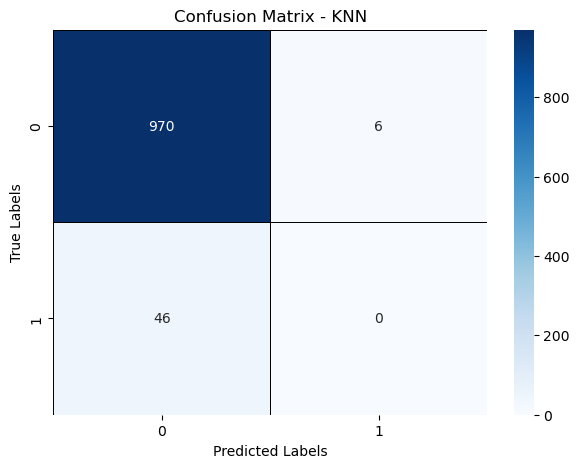

In [16]:
# 14. Visualize the confusion matrix for KNN
# We create a heatmap to visualize the confusion matrix. This provides a better understanding of the classifier's performance.
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_mat_knn, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - KNN')
plt.show()